# TMKP KGX category summary

This notebook summarizes the latest TMKP KGX release loaded into DuckDB. It groups the graph by node categories, edge categories, subject/object category flows, source records, qualifiers, and publication references.

Expected database: `downloads/tmkp/2026_04_21/tmkp.duckdb`.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

release = Path("downloads/tmkp/2026_04_21/tmkp.duckdb")
root_candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((root for root in root_candidates if (root / release).exists()), Path.cwd())
DB_PATH = ROOT / release

if not DB_PATH.exists():
    raise FileNotFoundError(f"DuckDB database not found: {DB_PATH}")

con = duckdb.connect(str(DB_PATH), read_only=True)

def sql(query: str) -> pd.DataFrame:
    return con.sql(query).df()

def barh(df: pd.DataFrame, x: str, y: str, title: str, limit: int = 20):
    plot_df = df.sort_values(x, ascending=False).head(limit).sort_values(x)
    height = max(4, min(12, 0.34 * len(plot_df) + 1.5))
    ax = plot_df.plot.barh(x=y, y=x, legend=False, figsize=(10, height), color="#456990")
    ax.set_title(title)
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel("")
    plt.tight_layout()
    return ax

print(DB_PATH)


/Users/cjm/repos/tmkp/downloads/tmkp/2026_04_21/tmkp.duckdb


## Release and table overview

In [2]:
display(sql("""
SELECT
  release_version,
  source,
  source_version,
  transform_version,
  node_norm_version,
  biolink_version,
  data
FROM release_metadata
"""))

display(sql("""
SELECT 'nodes' AS table_name, count(*) AS rows FROM nodes
UNION ALL SELECT 'edges', count(*) FROM edges
UNION ALL SELECT 'node_categories', count(*) FROM node_categories
UNION ALL SELECT 'node_equivalent_identifiers', count(*) FROM node_equivalent_identifiers
UNION ALL SELECT 'edge_publications', count(*) FROM edge_publications
UNION ALL SELECT 'edge_sources', count(*) FROM edge_sources
ORDER BY rows DESC
"""))


,release_version,source,source_version,transform_version,node_norm_version,biolink_version,data
0,2026_04_21,tmkp,tmkp-2023-03-05,6dadae40,2025sep1,4.3.6,https://kgx-storage.rtx.ai/releases/tmkp/2026_04_21/


,table_name,rows
0,edge_sources,3723976
1,edge_publications,3698859
2,edges,1861988
3,node_equivalent_identifiers,527966
4,node_categories,350912
5,nodes,32276


## Node categories

,primary_node_category,nodes,nodes_with_description,avg_information_content
0,biolink:Gene,14631,14631,90.72
1,biolink:Disease,8415,7807,91.09
2,biolink:SmallMolecule,6091,2909,94.27
3,biolink:ChemicalEntity,1337,308,74.35
4,biolink:Protein,1065,235,94.57
5,biolink:PhenotypicFeature,357,340,77.88
6,biolink:MolecularMixture,334,131,95.97
7,biolink:ChemicalMixture,43,31,92.65
8,biolink:ComplexMolecularMixture,3,0,NaN


<Axes: title={'center': 'Nodes by primary category'}, xlabel='nodes'>

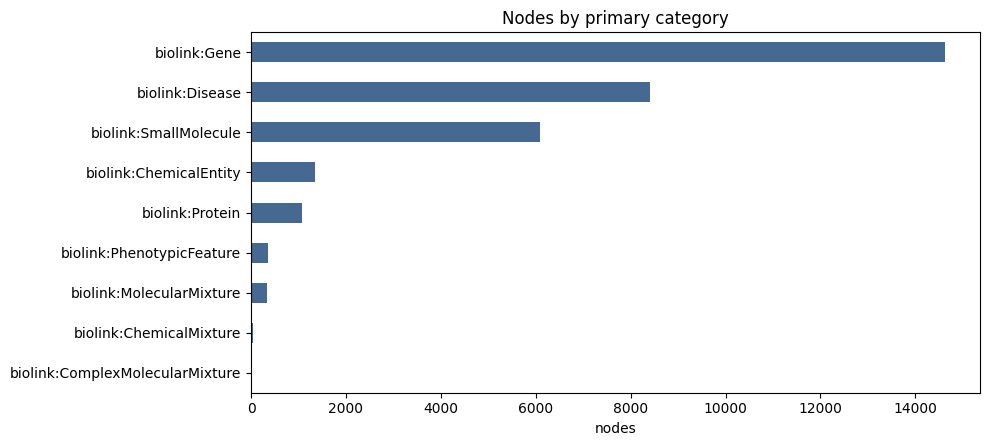

In [3]:
node_primary = sql("""
SELECT
  category[1] AS primary_node_category,
  count(*) AS nodes,
  count(description) AS nodes_with_description,
  round(avg(information_content), 2) AS avg_information_content
FROM nodes
GROUP BY 1
ORDER BY nodes DESC
""")
display(node_primary)
barh(node_primary, "nodes", "primary_node_category", "Nodes by primary category")


In [4]:
display(sql("""
SELECT category AS node_category, count(DISTINCT node_id) AS nodes
FROM node_categories
GROUP BY 1
ORDER BY nodes DESC
LIMIT 40
"""))

display(sql("""
SELECT
  category[1] AS primary_node_category,
  split_part(id, ':', 1) AS id_prefix,
  count(*) AS nodes
FROM nodes
GROUP BY 1, 2
ORDER BY nodes DESC
LIMIT 40
"""))


,node_category,nodes
0,biolink:NamedThing,32276
1,biolink:BiologicalEntity,24468
2,biolink:ThingWithTaxon,24468
3,biolink:ChemicalEntityOrGeneOrGeneProduct,23504
4,biolink:ChemicalEntityOrProteinOrPolypeptide,23504
5,biolink:PhysicalEssence,22439
6,biolink:PhysicalEssenceOrOccurrent,22439
7,biolink:OntologyClass,17017
8,biolink:MacromolecularMachineMixin,15696
9,biolink:GeneProductMixin,15696


,primary_node_category,id_prefix,nodes
0,biolink:Gene,NCBIGene,14631
1,biolink:Disease,MONDO,8413
2,biolink:SmallMolecule,CHEBI,4433
3,biolink:SmallMolecule,UNII,1436
4,biolink:Protein,UMLS,830
5,biolink:ChemicalEntity,DRUGBANK,690
6,biolink:ChemicalEntity,CHEBI,407
7,biolink:PhenotypicFeature,HP,357
8,biolink:Protein,UniProtKB,235
9,biolink:ChemicalEntity,UNII,231


## Edge categories and predicates

,primary_edge_category,predicate,edges,avg_confidence,median_confidence,max_evidence_count
0,biolink:ChemicalAffectsGeneAssociation,biolink:affects,645970,0.8126,0.8148,35042
1,biolink:CorrelatedGeneToDiseaseAssociation,biolink:affects,410126,0.7717,0.7779,30786
2,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,biolink:treats_or_applied_or_studied_to_treat,357802,0.7491,0.7590,37928
3,biolink:GeneRegulatesGeneAssociation,biolink:affects,301308,0.8684,0.8602,4624
4,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,biolink:contributes_to,146782,0.7204,0.7299,33977


<Axes: title={'center': 'Edges by primary edge category'}, xlabel='edges'>

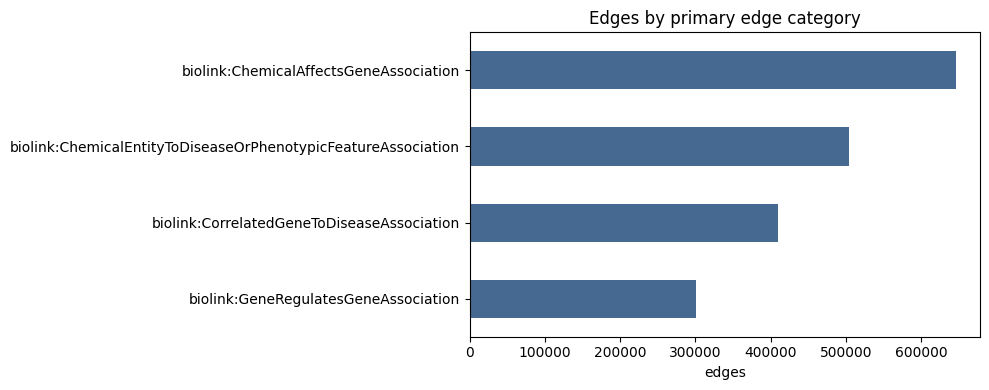

In [5]:
edge_primary = sql("""
SELECT
  category[1] AS primary_edge_category,
  predicate,
  count(*) AS edges,
  round(avg(has_confidence_score), 4) AS avg_confidence,
  round(median(has_confidence_score), 4) AS median_confidence,
  max(evidence_count) AS max_evidence_count
FROM edges
GROUP BY 1, 2
ORDER BY edges DESC
""")
display(edge_primary)

edge_category_counts = edge_primary.groupby("primary_edge_category", as_index=False)["edges"].sum()
barh(edge_category_counts, "edges", "primary_edge_category", "Edges by primary edge category")


In [6]:
display(sql("""
SELECT edge_category, count(*) AS edges
FROM edges, UNNEST(category) AS t(edge_category)
GROUP BY 1
ORDER BY edges DESC
"""))

display(sql("""
SELECT
  predicate,
  count(*) AS edges,
  round(avg(has_confidence_score), 4) AS avg_confidence,
  round(median(has_confidence_score), 4) AS median_confidence,
  round(quantile_cont(has_confidence_score, 0.95), 4) AS p95_confidence,
  sum(CASE WHEN has_confidence_score > 1 THEN 1 ELSE 0 END) AS edges_confidence_gt_1,
  round(avg(evidence_count), 2) AS avg_evidence_count,
  median(evidence_count) AS median_evidence_count,
  max(evidence_count) AS max_evidence_count
FROM edges
GROUP BY 1
ORDER BY edges DESC
"""))


,edge_category,edges
0,biolink:ChemicalAffectsGeneAssociation,645970
1,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,504584
2,biolink:CorrelatedGeneToDiseaseAssociation,410126
3,biolink:GeneRegulatesGeneAssociation,301504


,predicate,edges,avg_confidence,median_confidence,p95_confidence,edges_confidence_gt_1,avg_evidence_count,median_evidence_count,max_evidence_count
0,biolink:affects,1357404,0.8126,0.8124,1.0612,139278.0,6.98,1.0,35042
1,biolink:treats_or_applied_or_studied_to_treat,357802,0.7491,0.7590,0.9959,15944.0,20.14,2.0,37928
2,biolink:contributes_to,146782,0.7204,0.7299,0.9643,4048.0,7.44,1.0,33977


## Subject and object category flows

In [7]:
display(sql("""
SELECT
  coalesce(subject_primary_category, '<missing>') AS subject_category,
  predicate,
  coalesce(object_primary_category, '<missing>') AS object_category,
  count(*) AS edges,
  round(avg(has_confidence_score), 4) AS avg_confidence,
  max(evidence_count) AS max_evidence_count
FROM edges_enriched
GROUP BY 1, 2, 3
ORDER BY edges DESC
LIMIT 50
"""))

display(sql("""
SELECT
  subject_prefix,
  predicate,
  object_prefix,
  count(*) AS edges
FROM edges_enriched
GROUP BY 1, 2, 3
ORDER BY edges DESC
LIMIT 50
"""))


,subject_category,predicate,object_category,edges,avg_confidence,max_evidence_count
0,biolink:SmallMolecule,biolink:affects,biolink:Gene,479398,0.8285,35042
1,biolink:Gene,biolink:affects,biolink:Disease,398321,0.7698,30786
2,biolink:Gene,biolink:affects,biolink:Gene,297742,0.8678,4624
3,biolink:SmallMolecule,biolink:treats_or_applied_or_studied_to_treat,biolink:Disease,263705,0.7539,37928
4,biolink:SmallMolecule,biolink:contributes_to,biolink:Disease,97588,0.7240,6861
5,biolink:ChemicalEntity,biolink:affects,biolink:Gene,82676,0.7760,4082
6,biolink:Protein,biolink:affects,biolink:Gene,59477,0.7710,9741
7,biolink:ChemicalEntity,biolink:treats_or_applied_or_studied_to_treat,biolink:Disease,41016,0.7148,9008
8,biolink:Protein,biolink:treats_or_applied_or_studied_to_treat,biolink:Disease,32086,0.7515,30864
9,biolink:ChemicalEntity,biolink:contributes_to,biolink:Disease,18944,0.6817,4540


,subject_prefix,predicate,object_prefix,edges
0,CHEBI,biolink:affects,NCBIGene,500257
1,NCBIGene,biolink:affects,MONDO,398307
2,NCBIGene,biolink:affects,NCBIGene,297742
3,CHEBI,biolink:treats_or_applied_or_studied_to_treat,MONDO,266397
4,CHEBI,biolink:contributes_to,MONDO,104053
5,UMLS,biolink:affects,NCBIGene,57406
6,DRUGBANK,biolink:affects,NCBIGene,39666
7,UMLS,biolink:treats_or_applied_or_studied_to_treat,MONDO,32218
8,UNII,biolink:affects,NCBIGene,32045
9,UNII,biolink:treats_or_applied_or_studied_to_treat,MONDO,26497


## Sources

In [8]:
display(sql("""
SELECT
  resource_role,
  resource_id,
  count(*) AS source_records,
  count(DISTINCT edge_id) AS distinct_edges
FROM edge_sources
GROUP BY 1, 2
ORDER BY source_records DESC
"""))

display(sql("""
WITH source_rows AS (
  SELECT source.value AS source
  FROM edges e, json_each(e.sources) AS source
)
SELECT
  json_extract_string(source, '$.category[0]') AS source_primary_category,
  json_extract_string(source, '$.resource_role') AS resource_role,
  json_extract_string(source, '$.resource_id') AS resource_id,
  count(*) AS source_records
FROM source_rows
GROUP BY 1, 2, 3
ORDER BY source_records DESC
"""))

display(sql("""
SELECT
  e.category[1] AS primary_edge_category,
  s.resource_role,
  s.resource_id,
  count(*) AS source_records,
  count(DISTINCT e.id) AS distinct_edges
FROM edges e
JOIN edge_sources s ON s.edge_id = e.id
GROUP BY 1, 2, 3
ORDER BY source_records DESC
"""))


,resource_role,resource_id,source_records,distinct_edges
0,supporting_data_source,infores:pubmed,1861988,1861988
1,primary_knowledge_source,infores:text-mining-provider-targeted,1861988,1861988


,source_primary_category,resource_role,resource_id,source_records
0,biolink:RetrievalSource,supporting_data_source,infores:pubmed,1861988
1,biolink:RetrievalSource,primary_knowledge_source,infores:text-mining-provider-targeted,1861988


,primary_edge_category,resource_role,resource_id,source_records,distinct_edges
0,biolink:ChemicalAffectsGeneAssociation,primary_knowledge_source,infores:text-mining-provider-targeted,645970,645970
1,biolink:ChemicalAffectsGeneAssociation,supporting_data_source,infores:pubmed,645970,645970
2,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,primary_knowledge_source,infores:text-mining-provider-targeted,504584,504584
3,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,supporting_data_source,infores:pubmed,504584,504584
4,biolink:CorrelatedGeneToDiseaseAssociation,supporting_data_source,infores:pubmed,410126,410126
5,biolink:CorrelatedGeneToDiseaseAssociation,primary_knowledge_source,infores:text-mining-provider-targeted,410126,410126
6,biolink:GeneRegulatesGeneAssociation,supporting_data_source,infores:pubmed,301308,301308
7,biolink:GeneRegulatesGeneAssociation,primary_knowledge_source,infores:text-mining-provider-targeted,301308,301308


## Qualifier and assertion categories

In [9]:
display(sql("""
SELECT knowledge_level, agent_type, count(*) AS edges
FROM edges
GROUP BY 1, 2
ORDER BY edges DESC
"""))

display(sql("""
SELECT
  predicate,
  coalesce(qualified_predicate, '<none>') AS qualified_predicate,
  coalesce(object_aspect_qualifier, '<none>') AS object_aspect_qualifier,
  coalesce(object_direction_qualifier, '<none>') AS object_direction_qualifier,
  coalesce(subject_form_or_variant_qualifier, '<none>') AS subject_form_or_variant_qualifier,
  count(*) AS edges
FROM edges
GROUP BY 1, 2, 3, 4, 5
ORDER BY edges DESC
LIMIT 50
"""))


,knowledge_level,agent_type,edges
0,not_provided,text_mining_agent,1504186
1,knowledge_assertion,text_mining_agent,357802


,predicate,qualified_predicate,object_aspect_qualifier,object_direction_qualifier,subject_form_or_variant_qualifier,edges
0,biolink:affects,biolink:causes,activity_or_abundance,decreased,<none>,513967
1,biolink:affects,biolink:causes,activity_or_abundance,increased,<none>,433311
2,biolink:affects,biolink:contributes_to,<none>,<none>,modified_form,398030
3,biolink:treats_or_applied_or_studied_to_treat,<none>,<none>,<none>,<none>,357802
4,biolink:contributes_to,<none>,<none>,<none>,<none>,146782
5,biolink:affects,biolink:contributes_to,<none>,<none>,loss_of_function_variant_form,11013
6,biolink:affects,biolink:contributes_to,<none>,<none>,gain_of_function_variant_form,1083


## Publications and evidence

In [10]:
display(sql("""
WITH pub AS (
  SELECT
    edge_id,
    CASE
      WHEN publication LIKE 'PMID:%' THEN 'PMID'
      WHEN publication LIKE 'PMC%' THEN 'PMC'
      WHEN strpos(publication, ':') > 0 THEN split_part(publication, ':', 1)
      ELSE '<noprefix>'
    END AS publication_prefix
  FROM edge_publications
)
SELECT
  publication_prefix,
  count(*) AS publication_references,
  count(DISTINCT edge_id) AS distinct_edges
FROM pub
GROUP BY 1
ORDER BY publication_references DESC
"""))

display(sql("""
SELECT
  category[1] AS primary_edge_category,
  predicate,
  count(*) AS edges,
  sum(evidence_count) AS total_evidence_count,
  round(avg(evidence_count), 2) AS avg_evidence_count,
  median(evidence_count) AS median_evidence_count,
  max(evidence_count) AS max_evidence_count
FROM edges
GROUP BY 1, 2
ORDER BY total_evidence_count DESC
"""))


,publication_prefix,publication_references,distinct_edges
0,PMID,1868108,1049673
1,PMC,1830751,1077770


,primary_edge_category,predicate,edges,total_evidence_count,avg_evidence_count,median_evidence_count,max_evidence_count
0,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,biolink:treats_or_applied_or_studied_to_treat,357802,7204539.0,20.14,2.0,37928
1,biolink:ChemicalAffectsGeneAssociation,biolink:affects,645970,4849402.0,7.51,2.0,35042
2,biolink:CorrelatedGeneToDiseaseAssociation,biolink:affects,410126,2762084.0,6.73,2.0,30786
3,biolink:GeneRegulatesGeneAssociation,biolink:affects,301308,1867924.0,6.20,1.0,4624
4,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,biolink:contributes_to,146782,1092646.0,7.44,1.0,33977


## Quality checks by category

In [11]:
display(sql("""
WITH per_node AS (
  SELECT
    node_id,
    count(*) AS identifiers,
    count(DISTINCT equivalent_identifier) AS distinct_identifiers
  FROM node_equivalent_identifiers
  GROUP BY 1
)
SELECT
  count(*) AS nodes,
  sum(CASE WHEN identifiers > distinct_identifiers THEN 1 ELSE 0 END) AS nodes_with_duplicate_equivalent_identifiers,
  sum(identifiers - distinct_identifiers) AS duplicate_equivalent_identifier_entries
FROM per_node
"""))

display(sql("""
WITH repeated_spo AS (
  SELECT subject, predicate, object, count(*) AS edges
  FROM edges
  GROUP BY 1, 2, 3
  HAVING count(*) > 1
)
SELECT
  predicate,
  count(*) AS repeated_spo_triples,
  sum(edges - 1) AS duplicate_bare_spo_edges,
  max(edges) AS max_edges_for_one_spo
FROM repeated_spo
GROUP BY 1
ORDER BY duplicate_bare_spo_edges DESC
"""))

display(sql("""
SELECT
  category[1] AS primary_edge_category,
  predicate,
  count(*) AS edges_confidence_gt_1,
  round(max(has_confidence_score), 4) AS max_confidence
FROM edges
WHERE has_confidence_score > 1
GROUP BY 1, 2
ORDER BY edges_confidence_gt_1 DESC
"""))

display(sql("""
SELECT
  category[1] AS primary_edge_category,
  predicate,
  count(*) AS self_loop_edges
FROM edges
WHERE subject = object
GROUP BY 1, 2
ORDER BY self_loop_edges DESC
"""))


,nodes,nodes_with_duplicate_equivalent_identifiers,duplicate_equivalent_identifier_entries
0,32276,1799.0,34564.0


,predicate,repeated_spo_triples,duplicate_bare_spo_edges,max_edges_for_one_spo
0,biolink:affects,154200,154270.0,3


,primary_edge_category,predicate,edges_confidence_gt_1,max_confidence
0,biolink:GeneRegulatesGeneAssociation,biolink:affects,60376,1.4595
1,biolink:ChemicalAffectsGeneAssociation,biolink:affects,48554,1.4884
2,biolink:CorrelatedGeneToDiseaseAssociation,biolink:affects,30348,1.4629
3,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,biolink:treats_or_applied_or_studied_to_treat,15944,1.4396
4,biolink:ChemicalEntityToDiseaseOrPhenotypicFeatureAssociation,biolink:contributes_to,4048,1.3693


,primary_edge_category,predicate,self_loop_edges
0,biolink:GeneRegulatesGeneAssociation,biolink:affects,4101
1,biolink:ChemicalAffectsGeneAssociation,biolink:affects,4


## Example: top Metformin assertions

In [12]:
display(sql("""
SELECT
  subject,
  subject_name,
  predicate,
  object,
  object_name,
  object_primary_category,
  evidence_count,
  round(has_confidence_score, 4) AS confidence
FROM edges_enriched
WHERE subject = 'CHEBI:6801' OR lower(subject_name) = 'metformin'
ORDER BY evidence_count DESC
LIMIT 30
"""))


,subject,subject_name,predicate,object,object_name,object_primary_category,evidence_count,confidence
0,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0005148,type 2 diabetes mellitus,biolink:Disease,23355,0.6186
1,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0004992,cancer,biolink:Disease,13132,0.2627
2,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0005070,neoplasm,biolink:Disease,6876,0.3743
3,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0007254,breast cancer,biolink:Disease,5739,0.5377
4,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0008487,Androgen excess,biolink:Disease,5020,0.7394
5,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0011122,obesity,biolink:Disease,3497,0.5549
6,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0009831,malignant pancreatic neoplasm,biolink:Disease,3158,0.6266
7,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0005192,exocrine pancreatic carcinoma,biolink:Disease,3085,0.6651
8,CHEBI:6801,Metformin,biolink:affects,NCBIGene:3630,INS,biolink:Gene,2253,0.5425
9,CHEBI:6801,Metformin,biolink:treats_or_applied_or_studied_to_treat,MONDO:0008315,prostate cancer,biolink:Disease,2012,0.6071
